In [13]:
import pandas as pd

df_sales = pd.read_csv('/content/sales_data.csv')

# Ver quantidade de valores vazios
print('Quantidade de valores vazios: ')
print(df_sales.isnull().sum())
print('\n')

# Informações repitidas e suas quantidades
print('Informações repitidas e suas quantidades: ')
print(df_sales.duplicated().sum())

# Vizualização de dados duplicados
linhas_duplicadas = df_sales[df_sales.duplicated(keep=False)]

print('Dados duplicados na base: ')
print('\n')
print(linhas_duplicadas.sort_values(by='order_date'))

# Limpeza de dados
print('\n')
df_sales.drop_duplicates(inplace=True)
display(df_sales.head(10))

Quantidade de valores vazios: 
order_date           0
product_category     0
quantity             0
customer_region      0
sales_amount        21
dtype: int64


Informações repitidas e suas quantidades: 
15
Dados duplicados na base: 


     order_date product_category  quantity customer_region  sales_amount
280  2025-01-06           Mangás         5       São Paulo        176.99
111  2025-01-06           Mangás         5       São Paulo        176.99
232  2025-01-08           Mangás         5  Rio de Janeiro        176.04
136  2025-01-08           Mangás         5  Rio de Janeiro        176.04
171  2025-01-25            Jogos         3  Rio de Janeiro        941.79
38   2025-01-25            Jogos         3  Rio de Janeiro        941.79
308  2025-01-26   Action Figures         2       São Paulo       5880.00
89   2025-01-26   Action Figures         2       São Paulo       5880.00
145  2025-02-25       Acessórios         5       São Paulo        564.60
7    2025-02-25       Acessórios  

,order_date,product_category,quantity,customer_region,sales_amount
0,2025-02-01,Acessórios,4,Minas Gerais,525.56
1,2025-05-19,Action Figures,5,Minas Gerais,873.97
2,2025-04-18,Action Figures,2,Bahia,394.48
3,2025-02-23,Jogos,2,Bahia,613.79
4,2025-05-22,Consoles,1,São Paulo,3204.12
5,2025-04-22,Jogos,5,São Paulo,1370.15
6,2025-01-31,Consoles,1,Rio de Janeiro,3628.09
7,2025-02-25,Acessórios,5,São Paulo,564.60
8,2025-05-28,Mangás,5,Minas Gerais,176.40
9,2025-04-29,Acessórios,1,Rio de Janeiro,114.14


In [39]:
# Tarefa 1: Visualização Interativa com Plotly

# Importe o Plotly Express
import plotly.express as px

# Crie um boxplot interativo para a coluna sales_amount
fig = px.box(df_sales, y= ['sales_amount'], title ='Distribuição Interativa de Vendas')
fig.show()

In [28]:
# Tarefa 2: Análise Geográfica e Agrupamento

# Agrupe os dados por região e some as quantidades
tabela_regiao = df_sales.groupby(
    'customer_region')['quantity'].sum().reset_index()

# Ordenar do maior para o menor
tabela_regiao = tabela_regiao.sort_values(by='quantity',
                                          ascending=False)

print('Regiões com maior volume de compras em nossa loja: ')
print('\n')
print(tabela_regiao)

Regiões com maior volume de compras em nossa loja: 


  customer_region  quantity
4       São Paulo       211
3  Rio de Janeiro       194
1    Minas Gerais       183
2          Paraná       169
0           Bahia       168


/tmp/ipykernel_685/2847780219.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




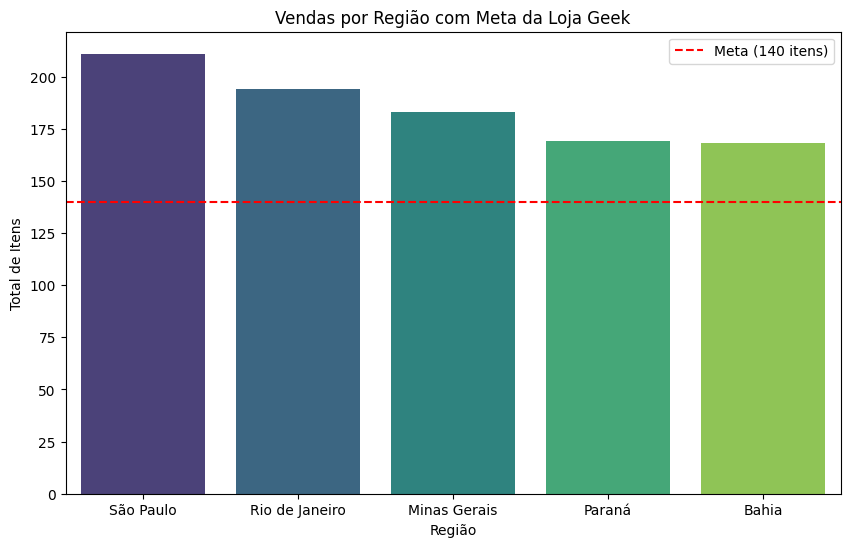

In [45]:
# Tarefa 3: Gráficos de Barras com Metas (Seaborn)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Crie o gráfico de barras
ax = sns.barplot(data=tabela_regiao, x='customer_region', y='quantity', palette='viridis')

# Adicione uma linha horizontal de meta no valor 140
plt.axhline(y=140, color='red', linestyle='--', label='Meta (140 itens)')
plt.title('Vendas por Região com Meta da Loja Geek')
plt.xlabel('Região')
plt.ylabel('Total de Itens')
plt.legend()
plt.show()

In [38]:
# Tarefa 4: Exportando Resultados para o Gestor

# Importe a biblioteca de arquivos do Colab
from google.colab import files

# Salve a tabela agregada em CSV no ambiente virtual
tabela_regiao.to_csv('vendas_por_regiao.csv', index=False)

# Force o download do arquivo para a sua máquina
files.download('vendas_por_regiao.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
# Tarefa 5: Análise de Negócios

# Pergunta 1: Interatividade vs. Gráficos Estáticos
# Ao passar o mouse sobre o Boxplot da Tarefa 1, quais os valores exatos (Mediana, Q1 e Q3) que você
# conseguiu extrair que não eram óbvios apenas "batendo o olho" num gráfico estático?
Mediana = '632.255'
Q1 = '276.895'
Q3 = '1,520.24'


print(f'O valor da Mediana é: {Mediana}')
print(f'O valor do Q1 é: {Q1}')
print(f'O valor do Q3 é: {Q3}')

print('\n')
# Pergunta 2: Acompanhamento de Metas Geográficas
# Analisando a linha vermelha tracejada na Tarefa 3, quais regiões alcançaram ou superaram o objetivo
# da loja? Como a Loja Geek poderia incentivar as regiões que ficaram abaixo da meta?
Regioes_que_alcançaram_objetivo = ('São Paulo',
    'Rio de Janeiro',
    'Minas Gerais',
    'Paraná',
    'Bahia')

regioes_uma_por_linha = '\n'.join(Regioes_que_alcançaram_objetivo)

print('As regiões que alcançaram o objetivo foram:')
print(regioes_uma_por_linha)

O valor da Mediana é: 632.255
O valor do Q1 é: 276.895
O valor do Q3 é: 1,520.24


As regiões que alcançaram o objetivo foram:
São Paulo
Rio de Janeiro
Minas Gerais
Paraná
Bahia
